<a href="https://colab.research.google.com/github/pratbharat/-advancecfdwithpratyush/blob/main/2D_Transient_Heat_Conduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
torch.autograd.set_detect_anomaly(True)
torch.manual_seed(128)

In [2]:
class NeuralNet(nn.Module):

    def __init__(self, input_dimension, output_dimension, n_hidden_layers, neurons, regularization_param, regularization_exp, retrain_seed):
        super(NeuralNet, self).__init__()
        # Number of input dimensions n
        self.input_dimension = input_dimension
        # Number of output dimensions m
        self.output_dimension = output_dimension
        # Number of neurons per layer
        self.neurons = neurons
        # Number of hidden layers
        self.n_hidden_layers = n_hidden_layers
        # Activation function
        self.activation = nn.Tanh()
        self.regularization_param = regularization_param
        # Regularization exponent
        self.regularization_exp = regularization_exp
        # Random seed for weight initialization

        self.input_layer = nn.Linear(self.input_dimension, self.neurons)
        self.hidden_layers = nn.ModuleList([nn.Linear(self.neurons, self.neurons) for _ in range(n_hidden_layers - 1)])
        self.output_layer = nn.Linear(self.neurons, self.output_dimension)
        self.retrain_seed = retrain_seed
        # Random Seed for weight initialization
        self.init_xavier()

    def forward(self, x):
        # The forward function performs the set of affine and non-linear transformations defining the network
        # (see equation above)
        x = self.activation(self.input_layer(x))
        for k, l in enumerate(self.hidden_layers):
            x = self.activation(l(x))
        return self.output_layer(x)

    def init_xavier(self):
        torch.manual_seed(self.retrain_seed)

        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                # torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)

        self.apply(init_weights)

    def regularization(self):
        reg_loss = 0
        for name, param in self.named_parameters():
            if 'weight' in name:
                reg_loss = reg_loss + torch.norm(param, self.regularization_exp)
        return self.regularization_param * reg_loss


def fit(model, training_set, num_epochs, optimizer, p, verbose=True):
    history = list()

    # Loop over epochs
    for epoch in range(num_epochs):
        if verbose: print("################################ ", epoch, " ################################")

        running_loss = list([0])

        # Loop over batches
        for j, (x_train_, u_train_) in enumerate(training_set):
            def closure():
                # zero the parameter gradients
                optimizer.zero_grad()
                # forward + backward + optimize
                u_pred_ = model(x_train_)
                # Item 1. below
                loss = torch.mean((u_pred_.reshape(-1, ) - u_train_.reshape(-1, )) ** p) + model.regularization()
                # Item 2. below
                loss.backward()
                # Compute average training loss over batches for the current epoch
                running_loss[0] += loss.item()
                return loss

            # Item 3. below
            optimizer.step(closure=closure)

        if verbose: print('Loss: ', (running_loss[0] / len(training_set)))
        history.append(running_loss[0])

    return history

Consider the two-dimensional heat equation:

$$
T_t(t,x,y) = T_{xx}(t,x,y) + T_{yy}(t,x,y) + Q(x,y,t),
\quad t\in[0,T],~ (x,y)\in [-1,1]^2
$$

with zero Neumann boundary conditions

$$
\frac{\partial T}{\partial n}(t,x,y)=0,
\qquad (x,y)\in \partial([-1,1]^2),
$$

that is,

$$
T_x(t,-1,y)=T_x(t,1,y)=0,\qquad
T_y(t,x,-1)=T_y(t,x,1)=0.
$$

and initial condition

$$
T(x,y,0) = T_0(x,y) = 25.
$$

We want to obtain an approximate solution of the heat equation
\(T : [0,T]\times[-1,1]^2 \mapsto \mathbb{R}\)
with physics informed neural networks (PINNs).

To do so, we approximate the underlying solution with a feedforward dense neural network with tunable parameters \(\theta\):

$$
T_\theta(t,x,y) \approx T(t,x,y).
$$

Define the following residuals:

- Interior residual given by

$$
r_{int,\theta}(t,x,y)
:=
T_{\theta,t}(t,x,y)
-
T_{\theta,xx}(t,x,y)
-
T_{\theta,yy}(t,x,y)
-
Q(x,y,t),
\quad
\forall~ t\in[0,T],~ (x,y)\in[-1,1]^2.
$$


- Spatial boundary residual given by

Left and right boundaries:

$$
r_{sb,\theta}(t,-1,y)=T_{\theta,x}(t,-1,y),
\qquad
r_{sb,\theta}(t,1,y)=T_{\theta,x}(t,1,y),
\quad
\forall~t\in(0,T],~ y\in[-1,1].
$$

Bottom and top boundaries:

$$
r_{sb,\theta}(t,x,-1)=T_{\theta,y}(t,x,-1),
\qquad
r_{sb,\theta}(t,x,1)=T_{\theta,y}(t,x,1),
\quad
\forall~t\in(0,T],~ x\in[-1,1].
$$


- Temporal boundary residual given by

$$
r_{tb,\theta}(x,y)
:=
T_\theta(0,x,y) - T_0(x,y),
\quad
\forall~(x,y)\in[-1,1]^2.
$$


and compute the corresponding loss functions:

$$
L_{int}(\theta)
=
\int_{[0,T]\times[-1,1]^2}
r_{int,\theta}^2(t,x,y)\, dt\, dx\, dy,
$$

$$
\begin{aligned}
L_{sb}(\theta)
&=
\int_0^T \!\int_{-1}^1
\left[
r_{sb,\theta}^2(t,-1,y)
+
r_{sb,\theta}^2(t,1,y)
\right] dy\, dt
\\
&\quad+
\int_0^T \!\int_{-1}^1
\left[
r_{sb,\theta}^2(t,x,-1)
+
r_{sb,\theta}^2(t,x,1)
\right] dx\, dt,
\end{aligned}
$$

$$
L_{tb}(\theta)
=
\int_{[-1,1]^2}
r_{tb,\theta}^2(x,y)\, dx\, dy.
$$


The loss functions include integrals that can be approximated by a suitable quadrature rule. We use quasi Monte-Carlo and accordingly define the following training sets:

$$
S_{int} = \{(t_n,x_n,y_n)\},
\quad
1\le n\le N_{int},\quad
(t_n,x_n,y_n)\in[0,T]\times[-1,1]^2,
$$

$$
S_{sb,x} = \{(t_n,y_n)\},
\quad
1\le n\le N_{sb},\quad
(t_n,y_n)\in [0,T]\times[-1,1],
$$

$$
S_{sb,y} = \{(t_n,x_n)\},
\quad
1\le n\le N_{sb},\quad
(t_n,x_n)\in [0,T]\times[-1,1],
$$

$$
S_{tb} = \{(x_n,y_n,T_0(x_n,y_n))\},
\quad
1\le n\le N_{tb},\quad
(x_n,y_n)\in[-1,1]^2.
$$

with the training input points corresponding to low-discrepancy Sobol sequences.

The discrete loss functions become

$$
L_{int}(\theta)
=
\frac{1}{N_{int}}
\sum_{n=1}^{N_{int}}
r_{int,\theta}^2(t_n,x_n,y_n),
$$

$$
\begin{aligned}
L_{sb}(\theta)
&=
\frac{1}{N_{sb}}
\sum r_{sb,\theta}^2(t_n,-1,y_n)
+
\frac{1}{N_{sb}}
\sum r_{sb,\theta}^2(t_n,1,y_n)
\\
&\quad+
\frac{1}{N_{sb}}
\sum r_{sb,\theta}^2(t_n,x_n,-1)
+
\frac{1}{N_{sb}}
\sum r_{sb,\theta}^2(t_n,x_n,1),
\end{aligned}
$$

$$
L_{tb}(\theta)
=
\frac{1}{N_{tb}}
\sum_{n=1}^{N_{tb}}
r_{tb,\theta}^2(x_n,y_n).
$$

and we solve the following minimization problem:

$$
\theta^\ast =
\arg\min_{\theta}
\Big(
L_{int}(\theta) + \lambda_u L_u(\theta)
\Big),
$$

with

$$
L_u(\theta) = L_{tb}(\theta) + L_{sb}(\theta).
$$


## 2D Heat Conduction PINN (Neumann BC, heat source)

We solve the 2D heat equation with temperature field \(T(t,x,y)\):

$$
T_t = T_{xx} + T_{yy} + Q(x,y,t), \quad (x,y)\in[-1,1]^2,\; t\in[0,T].
$$

Neumann BC (zero flux) on all sides:

$$
\frac{\partial T}{\partial n}=0 \quad\text{on } \partial([-1,1]^2).
$$


Initial condition:
$$
T(x,y,0)=25.
$$

We approximate T with a feedforward network $$(T_\theta(t,x,y))$$ and define:
- interior residual $$ (r_{int} = T_{\theta,t} - T_{\theta,xx} - T_{\theta,yy} - Q),$$
- boundary residuals enforce normal derivative = 0,
- initial residual enforces $$(T_\theta(t=0,x,y)=25).$$

The training points are sampled with low-discrepancy Sobol sequences.


In [5]:
# 2D PINN class for heat equation with Neumann BC and heat source
# NOTE: keep or replace with your NeuralNet implementation
# from your_module import NeuralNet

class Pinns2D:
    def __init__(self, n_int_, n_sb_, n_tb_, T_final=1, heat_source=None, device='cpu'):
        """
        n_int_: number of interior Sobol points
        n_sb_ : number of boundary Sobol points per side
        n_tb_ : number of initial-condition Sobol points
        T_final: final time (upper bound for t in [0, T_final])
        heat_source: callable Q(inputs) -> tensor shape (N,1) where inputs are (t,x,y)
                      if None, Q is assumed zero
        """
        self.device = device
        self.n_int = n_int_
        self.n_sb = n_sb_
        self.n_tb = n_tb_
        self.T_final = T_final
        self.heat_source = heat_source if heat_source is not None else (lambda inp: torch.zeros((inp.shape[0],1), device=inp.device))

        # domain_extrema: rows = dims (t,x,y), cols = [min, max]
        self.domain_extrema = torch.tensor([[0.0, float(self.T_final)],   # t
                                            [-1.0, 1.0],  # x
                                            [-1.0, 1.0]], # y
                                           dtype=torch.float32, device=self.device)

        # number of space dimensions
        self.space_dimensions = 2

        # parameter to balance data & PDE (you can tune)
        self.lambda_u = 10.0

        # Neural network approximator: input_dimension = 3 (t,x,y)
        # Replace NeuralNet(...) with your network constructor if different
        self.approximate_solution = NeuralNet(
            input_dimension=self.domain_extrema.shape[0],
            output_dimension=1,
            n_hidden_layers=4,
            neurons=40,
            regularization_param=0.,
            regularization_exp=2.,
            retrain_seed=42
        )
        # push network to device if needed
        self.approximate_solution.to(self.device)

        # Sobol sampler
        self.soboleng = torch.quasirandom.SobolEngine(dimension=self.domain_extrema.shape[0])

        # assemble datasets (and store boundary normals to compute Neumann residuals)
        (self.training_set_sb,
         self.training_set_tb,
         self.training_set_int) = self.assemble_datasets()

    def convert(self, tens):
        """ Map points in [0,1]^3 to domain [tmin,tmax] x [xmin,xmax] x [ymin,ymax] """
        assert (tens.shape[1] == self.domain_extrema.shape[0])
        mins = self.domain_extrema[:, 0]
        maxs = self.domain_extrema[:, 1]
        return tens * (maxs - mins) + mins

    def initial_condition(self, spatial_coords):
        """
        spatial_coords: tensor shape (N,2) or (N,3) (if 3, we ignore t).
        Returns initial temperature 25 degC for each spatial point.
        """
        N = spatial_coords.shape[0]
        return 25.0 * torch.ones((N, 1), dtype=torch.float32, device=self.device)
    '''
    def exact_solution(self, inputs):
        """
        Placeholder exact solution. If you have an analytic solution, replace this.
        inputs: shape (N,3) [t,x,y]
        Returns: (N,1) tensor
        """
        # no closed-form provided (with arbitrary Q) -> use initial 25 as placeholder
        return 25.0 * torch.ones((inputs.shape[0], 1), dtype=torch.float32, device=self.device)
    '''
    ################################################################################
    # Create training points for initial (temporal boundary) condition
    def add_temporal_boundary_points(self):
        """
        Sample n_tb Sobol points in domain, set t=0, outputs = initial_condition(x,y)
        Returns:
            input_tb: (N_tb,3) with columns [t=0, x, y]
            output_tb: (N_tb,1) temperature (25)
        """
        pts = self.soboleng.draw(self.n_tb).to(self.device)
        pts = self.convert(pts)  # (t,x,y)
        pts[:, 0] = self.domain_extrema[0, 0]  # set t = t_min = 0
        input_tb = pts
        # spatial coords at columns 1,2
        spatial = input_tb[:, 1:3]
        output_tb = self.initial_condition(spatial)
        return input_tb, output_tb

    # Create training points for spatial Neumann boundaries
    def add_spatial_boundary_points(self):
        """
        Create boundary points for all four edges.
        For each side we sample n_sb points (t plus the other spatial coordinate).
        Returns:
            input_sb: (4*n_sb, 3) [t,x,y]
            output_sb: (4*n_sb, 1) zeros (desired normal derivative = 0)
            normals_sb: (4*n_sb, 2) normal vectors (n_x, n_y) for each sample
        The DataLoader will contain these three tensors so the training loop can get normals.
        """
        N = self.n_sb
        # sample N points in full domain (we'll overwrite the appropriate coordinate)
        base = self.soboleng.draw(N).to(self.device)
        base = self.convert(base)  # (t,x,y)

        inputs = []
        normals = []
        outputs = []

        # Left side (x = -1): normal points outward along negative x -> (-1, 0)
        left = base.clone()
        left[:, 1] = self.domain_extrema[1, 0]  # x = xmin = -1
        inputs.append(left)
        normals.append(torch.tensor([[-1.0, 0.0]]).repeat(N, 1).to(self.device))
        outputs.append(torch.zeros((N, 1), device=self.device))

        # Right side (x = 1): normal (1,0)
        right = base.clone()
        right[:, 1] = self.domain_extrema[1, 1]  # x = xmax = 1
        inputs.append(right)
        normals.append(torch.tensor([[1.0, 0.0]]).repeat(N, 1).to(self.device))
        outputs.append(torch.zeros((N, 1), device=self.device))

        # Bottom side (y = -1): normal (0, -1)
        bottom = base.clone()
        bottom[:, 2] = self.domain_extrema[2, 0]  # y = ymin = -1
        inputs.append(bottom)
        normals.append(torch.tensor([[0.0, -1.0]]).repeat(N, 1).to(self.device))
        outputs.append(torch.zeros((N, 1), device=self.device))

        # Top side (y = 1): normal (0, 1)
        top = base.clone()
        top[:, 2] = self.domain_extrema[2, 1]  # y = ymax = 1
        inputs.append(top)
        normals.append(torch.tensor([[0.0, 1.0]]).repeat(N, 1).to(self.device))
        outputs.append(torch.zeros((N, 1), device=self.device))

        input_sb = torch.cat(inputs, dim=0)
        normals_sb = torch.cat(normals, dim=0)
        output_sb = torch.cat(outputs, dim=0)

        return input_sb, output_sb, normals_sb

    # Interior samplers (same as original)
    def add_interior_points(self):
        input_int = self.convert(self.soboleng.draw(self.n_int).to(self.device))
        output_int = torch.zeros((input_int.shape[0], 1), device=self.device)
        return input_int, output_int

    def assemble_datasets(self):
        input_sb, output_sb, normals_sb = self.add_spatial_boundary_points()   # S_sb
        input_tb, output_tb = self.add_temporal_boundary_points()              # S_tb
        input_int, output_int = self.add_interior_points()                     # S_int

        # Create dataloaders
        # For SB we include normals in the TensorDataset so training loop gets them
        dataset_sb = TensorDataset(input_sb, output_sb, normals_sb)
        training_set_sb = DataLoader(dataset_sb, batch_size=2*self.space_dimensions*self.n_sb, shuffle=False)

        training_set_tb = DataLoader(TensorDataset(input_tb, output_tb), batch_size=self.n_tb, shuffle=False)
        training_set_int = DataLoader(TensorDataset(input_int, output_int), batch_size=self.n_int, shuffle=False)

        return training_set_sb, training_set_tb, training_set_int

    ################################################################################
    # Apply initial condition (temporal boundary) -> returns predicted T at t=0 points
    def apply_initial_condition(self, input_tb):
        # input_tb shape (N,3)
        input_tb = input_tb.to(self.device)
        u_pred_tb = self.approximate_solution(input_tb)
        return u_pred_tb

    # For Neumann BC: compute normal derivative at boundary points
    def apply_boundary_conditions(self, input_sb, normals_sb):
        """
        input_sb: (N,3) [t,x,y]
        normals_sb: (N,2) normals for each sample (n_x, n_y)
        Returns:
            normal_deriv: (N,1) approximate normal derivative n . grad_{x,y} T
        """
        input_sb = input_sb.to(self.device)
        input_sb.requires_grad_(True)
        u_pred_sb = self.approximate_solution(input_sb)  # (N,1)

        # compute gradients of u_pred sum wrt inputs
        grads = torch.autograd.grad(outputs=u_pred_sb.sum(), inputs=input_sb, create_graph=True)[0]  # (N,3)
        # grads columns: [u_t, u_x, u_y]
        u_x = grads[:, 1:2]
        u_y = grads[:, 2:3]
        normals = normals_sb.to(self.device)
        # compute normal derivative n_x * u_x + n_y * u_y
        normal_deriv = normals[:, 0:1] * u_x + normals[:, 1:2] * u_y
        return normal_deriv

    # PDE residual for interior points: r = T_t - T_xx - T_yy - Q
    def compute_pde_residual(self, input_int):
        input_int = input_int.to(self.device)
        input_int.requires_grad_(True)

        u = self.approximate_solution(input_int)        # (N,1)
        # first derivatives (u_t, u_x, u_y)
        grad_u = torch.autograd.grad(outputs=u.sum(), inputs=input_int, create_graph=True)[0]  # (N,3)
        u_t = grad_u[:, 0:1]
        u_x = grad_u[:, 1:2]
        u_y = grad_u[:, 2:3]

        # second derivatives: u_xx and u_yy
        u_xx = torch.autograd.grad(outputs=u_x.sum(), inputs=input_int, create_graph=True)[0][:, 1:2]
        u_yy = torch.autograd.grad(outputs=u_y.sum(), inputs=input_int, create_graph=True)[0][:, 2:3]

        # compute heat source Q at interior points
        Qval = self.heat_source(input_int)  # expected shape (N,1)
        # residual
        r = u_t - u_xx - u_yy - Qval
        return r

    # Compute total loss
    def compute_loss(self, inp_train_sb, u_train_sb, normals_train_sb, inp_train_tb, u_train_tb, inp_train_int, verbose=True):
        """
        Inputs:
          inp_train_sb: (Nb,3), u_train_sb: (Nb,1) (should be zeros), normals_train_sb: (Nb,2)
          inp_train_tb: (Nt,3), u_train_tb: (Nt,1)
          inp_train_int: (Ni,3)
        """
        # Move to device
        inp_train_sb = inp_train_sb.to(self.device)
        u_train_sb = u_train_sb.to(self.device)
        normals_train_sb = normals_train_sb.to(self.device)
        inp_train_tb = inp_train_tb.to(self.device)
        u_train_tb = u_train_tb.to(self.device)
        inp_train_int = inp_train_int.to(self.device)

        # --- Boundary (Neumann) residuals: compute normal derivative and compare to zero
        normal_deriv = self.apply_boundary_conditions(inp_train_sb, normals_train_sb)  # (Nb,1)
        # target is zero flux -> residual = normal_deriv - 0
        r_sb = normal_deriv - u_train_sb  # u_train_sb expected zeros
        loss_sb = torch.mean(r_sb ** 2)

        # --- Temporal boundary (initial condition)
        u_pred_tb = self.apply_initial_condition(inp_train_tb)
        r_tb = u_pred_tb - u_train_tb
        loss_tb = torch.mean(r_tb ** 2)

        # --- Interior PDE residual
        r_int = self.compute_pde_residual(inp_train_int)
        loss_int = torch.mean(r_int ** 2)

        # Combine (same form as your original): log10(lambda_u*(loss_sb+loss_tb) + loss_int)
        combined = self.lambda_u * (loss_sb + loss_tb) + loss_int
        # small eps to avoid log10(0)
        loss = torch.log10(combined + 1e-12)

        if verbose:
            print(f"loss_int={loss_int.item():.3e}, loss_sb={loss_sb.item():.3e}, loss_tb={loss_tb.item():.3e}, total={loss.item():.3e}")

        return loss

    ################################################################################
    def fit(self, num_epochs, optimizer, verbose=True):
        history = list()

        # Loop over epochs
        for epoch in range(num_epochs):
            if verbose:
                print("################################ ", epoch, " ################################")

            # training_set_sb yields tuples (inp_sb, out_sb, normals_sb)
            for j, ((inp_train_sb, u_train_sb, normals_train_sb), (inp_train_tb, u_train_tb), (inp_train_int, u_train_int)) \
                    in enumerate(zip(self.training_set_sb, self.training_set_tb, self.training_set_int)):
                def closure():
                    optimizer.zero_grad()
                    loss = self.compute_loss(inp_train_sb, u_train_sb, normals_train_sb, inp_train_tb, u_train_tb, inp_train_int, verbose=verbose)
                    loss.backward()
                    history.append(loss.item())
                    return loss

                optimizer.step(closure=closure)

        print('Final Loss: ', history[-1])
        return history

    ################################################################################
    def plotting(self, nplot=20000):
        # Draw many Sobol points for visualization
        inputs = self.soboleng.draw(nplot).to(self.device)
        inputs = self.convert(inputs)
        inputs.requires_grad_(False)

        # Evaluate approximate solution
        output = self.approximate_solution(inputs).reshape(-1, )

        # Plot approximate solution
        plt.figure(figsize=(8, 6), dpi=120)
        sc = plt.scatter(inputs[:, 1].detach().cpu().numpy(),  # x
                         inputs[:, 0].detach().cpu().numpy(),  # t
                         c=output.detach().cpu().numpy(),
                         cmap="jet", s=6)
        plt.xlabel("x")
        plt.ylabel("t")
        plt.title("Approximate Solution")
        plt.colorbar(sc)
        plt.grid(True, which="both", ls=":")
        plt.show()


    def plotting_2d_xy(self, time_slices=[0.0, 0.1, 0.2, 0.3], n_points=100):
        """
        Plot the temperature T(x,y) on the xy-plane for several time slices.

        Parameters
        ----------
        time_slices : list of float
            List of time steps at which to plot the temperature.
        n_points : int
            Number of points in x and y directions for grid evaluation.
        """
        x = torch.linspace(-1, 1, n_points)
        y = torch.linspace(-1, 1, n_points)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        X_flat = X.reshape(-1, 1)
        Y_flat = Y.reshape(-1, 1)

        n_plots = len(time_slices)
        fig, axs = plt.subplots(1, n_plots, figsize=(4*n_plots, 4), dpi=120)

        for i, t_val in enumerate(time_slices):
            T_val = torch.full_like(X_flat, t_val)  # create t column
            inputs = torch.cat([T_val, X_flat, Y_flat], dim=1).to(self.device)

            T_pred = self.approximate_solution(inputs).detach().cpu().numpy().reshape(n_points, n_points)

            im = axs[i].imshow(T_pred.T, extent=[-1,1,-1,1], origin='lower', cmap='jet')
            axs[i].set_title(f"t = {t_val:.2f}")
            axs[i].set_xlabel("x")
            axs[i].set_ylabel("y")
            fig.colorbar(im, ax=axs[i])

        plt.tight_layout()
        plt.show()



# Step by Step: Physics-Informed Neural Network (PINN) for 2D Transient Heat Equation

This notebook implements a **Physics-Informed Neural Network (PINN)** to solve the **2D transient heat conduction equation** with **Neumann boundary conditions** (zero flux) and a **heat source** term.  
The approach combines the governing **PDE physics** with data-driven **neural network learning** to approximate the temperature field \( T(t, x, y) \) over a spatio-temporal domain.

---

## ⚙️ Governing Equation

The 2D transient heat equation with a heat source ( Q(t, x, y) ) is:

$$
\frac{\partial T}{\partial t} = \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} + Q(t, x, y)
$$

### Subject to:
- **Initial Condition (IC):**
  $$
  T(0, x, y) = 25^\circ C
  $$
- **Neumann Boundary Conditions (BC):**
  $$
  \frac{\partial T}{\partial n} = 0 \quad \text{on all spatial boundaries}
  $$
  where $$ \frac{\partial T}{\partial n} = n_x \frac{\partial T}{\partial x} + n_y \frac{\partial T}{\partial y}  $$

---

## 🧩 High-Level Structure of the Code

### 1. **Network Definition**
- A fully connected neural network `NeuralNet` approximates $$ T(t, x, y) $$
- Inputs:  t, x, y
- Output:  T
- Typical architecture: 4 hidden layers × 40 neurons each, with smooth activation functions.

### 2. **Domain Definition**
- Domain:  t in $[0, T_{final}] $ , $ x, y \in [-1, 1] $
- The domain is sampled using **Sobol sequences** for quasi-random point generation:
  - Interior points → Enforce PDE residuals
  - Boundary points → Enforce Neumann BC
  - Temporal boundary $(t=0)$ → Enforce initial condition

### 3. **Heat Source Function**
- A user-defined function \( Q(t, x, y) \) can be specified.
- Default: \( Q = 0 \) (no heat generation).

---

## Algorithm: PINN for 2D Transient Heat Equation

**Step 1: Initialize Parameters**
- Set number of samples:
  - $ n_{int} $: interior points
  - $ n_{sb} $: boundary points per side
  - $ n_{tb} $: temporal boundary points
- Define final time $ T_{final} $ and heat source function $ Q(t, x, y) $.

---

**Step 2: Generate Training Data (Sobol Sampling)**
- **Interior Points:** Randomly sample inside the domain for enforcing PDE.
- **Boundary Points:** Sample points at $ x = \pm 1 $ and $ y = \pm 1 $ with associated normals.
- **Temporal Boundary Points:** Set $ t = 0 $ for enforcing initial condition.

---

**Step 3: Define the Loss Components**
The total loss combines physics and boundary constraints:

$$
\mathcal{L}_{total} = \log_{10}\left[ \lambda_u \left( \mathcal{L}_{BC} + \mathcal{L}_{IC} \right) + \mathcal{L}_{PDE} \right]
$$

where:
- $$ \mathcal{L}_{BC} = \text{MSE}(\partial T / \partial n - 0) $$
- $$\mathcal{L}_{IC} = \text{MSE}(T_{pred}(0,x,y) - 25) $$
- $$ \mathcal{L}_{PDE} = \text{MSE}(T_t - T_{xx} - T_{yy} - Q) $$
- $ \lambda_u $: scaling factor to balance PDE and data terms.

---

**Step 4: Compute Gradients (Autograd)**
- Use `torch.autograd.grad` to compute:
  - First derivatives: $ T_t, T_x, T_y $
  - Second derivatives: $ T_{xx}, T_{yy} $
- Evaluate PDE residuals and boundary normal derivatives.

---

**Step 5: Optimization Loop**
- Use gradient-based optimizer (e.g., **LBFGS**, **Adam**).
- For each epoch:
  1. Compute total loss.
  2. Backpropagate gradients.
  3. Update network weights.

---

**Step 6: Training and Monitoring**
- The training history stores the loss at each iteration.
- Periodic printouts display:
  - Interior PDE loss
  - Boundary loss
  - Initial condition loss
  - Total loss (log-scaled)

---

**Step 7: Post-Training Evaluation**
- After training, the network approximates:
  $ T_{PINN}(t, x, y) $
- You can visualize:
  - Temperature field evolution over time.
  - Heat distribution contours.
  - Comparison with analytical or numerical solutions (if available).

---

## 🧾 Summary

| Component | Description |
|------------|-------------|
| **PDE** | Transient 2D heat conduction with source |
| **BC Type** | Neumann (zero flux) |
| **IC** | $ T = 25^\circ C $ at $ t = 0 $ |
| **Network** | Fully connected NN: input $(t, x, y)$ → output T |
| **Loss Terms** | PDE residual, BC residual, IC residual |
| **Sampling** | Sobol quasi-random sampling |
| **Optimizer** | LBFGS / Adam |
| **Output** | Learned approximation of $ T(t, x, y) $ |

---

📘 **In essence:**  
This PINN framework enforces **physical consistency** of the heat conduction equation while **learning the temperature field** directly from the PDE constraints — without requiring labeled data.


In [11]:
def constant_heat_source(inputs):
    """
    Constant heat source Q(t, x, y) = q0
    inputs: tensor of shape (N, 3) [t, x, y]
    returns: tensor of shape (N, 1)
    """
    q0 = 10.0  # constant heat generation rate
    return q0 * torch.ones((inputs.shape[0], 1), device=inputs.device)

In [12]:
# Solve the 2D heat equation:
# T_t = T_xx + T_yy + Q(x, y, t)
# (t, x, y) in [0, 0.1] x [-1, 1] x [-1, 1]
# Neumann BC on all spatial boundaries
# Initial temperature T(x, y, 0) = 25

# Number of training points
n_int = 5000        # interior points
n_sb = 2000         # spatial boundary points (for 4 sides)
n_tb = 2000         # temporal boundary points (initial condition)

# Instantiate the 2D PINN
pinn = Pinns2D(n_int, n_sb, n_tb, heat_source=constant_heat_source)
# If you want to plug your own heat source:
# pinn = Pinns2D(n_int, n_sb, n_tb, Q_function=my_heat_source_function)


In [13]:
n_epochs = 1
optimizer_LBFGS = optim.LBFGS(pinn.approximate_solution.parameters(),
                              lr=float(0.5),
                              max_iter=50000,
                              max_eval=50000,
                              history_size=150,
                              line_search_fn="strong_wolfe",
                              tolerance_change=1.0 * np.finfo(float).eps)
optimizer_ADAM = optim.Adam(pinn.approximate_solution.parameters(),
                            lr=float(0.001))

################################  0  ################################
loss_int=1.299e+02, loss_sb=4.465e-01, loss_tb=6.267e+02, total=3.806e+00
loss_int=1.281e+02, loss_sb=4.572e-01, loss_tb=6.176e+02, total=3.800e+00
loss_int=1.160e+02, loss_sb=9.583e-01, loss_tb=5.425e+02, total=3.744e+00
loss_int=7.075e+01, loss_sb=3.007e+00, loss_tb=4.385e+02, total=3.652e+00
loss_int=7.152e+01, loss_sb=9.636e-01, loss_tb=2.913e+02, total=3.476e+00
loss_int=9.641e+01, loss_sb=5.161e-02, loss_tb=8.028e+01, total=2.954e+00
loss_int=9.955e+01, loss_sb=8.070e-04, loss_tb=2.246e+01, total=2.511e+00
loss_int=9.892e+01, loss_sb=1.872e-03, loss_tb=5.198e-01, total=2.018e+00
loss_int=9.808e+01, loss_sb=3.841e-03, loss_tb=1.064e+00, total=2.036e+00
loss_int=9.859e+01, loss_sb=2.577e-03, loss_tb=1.602e-03, total=1.994e+00
loss_int=9.839e+01, loss_sb=2.867e-03, loss_tb=2.147e-03, total=1.993e+00
loss_int=9.628e+01, loss_sb=7.278e-03, loss_tb=2.472e-02, total=1.985e+00
loss_int=9.192e+01, loss_sb=2.242e-02, los

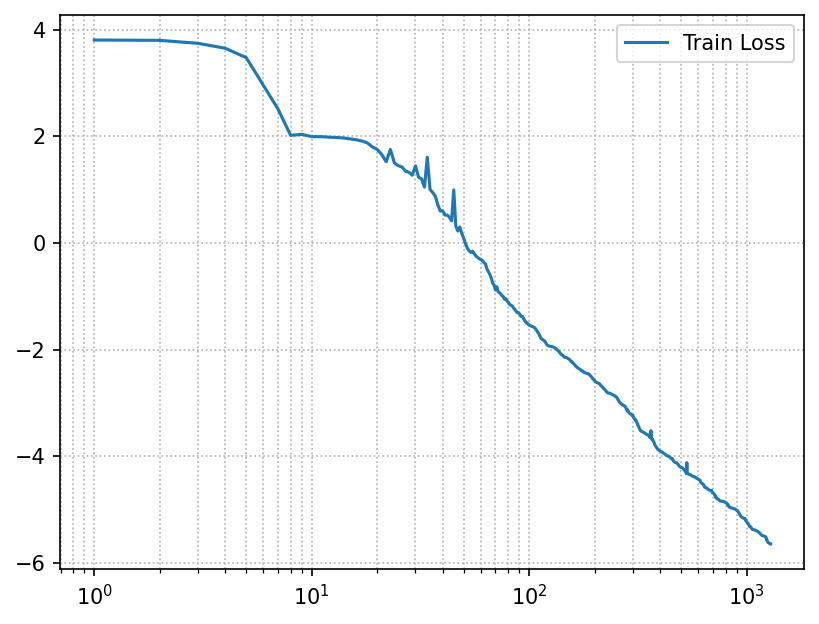

In [14]:
hist = pinn.fit(num_epochs=n_epochs,
                optimizer=optimizer_LBFGS,
                verbose=True)

plt.figure(dpi=150)
plt.grid(True, which="both", ls=":")
plt.plot(np.arange(1, len(hist) + 1), hist, label="Train Loss")
plt.xscale("log")
plt.legend()

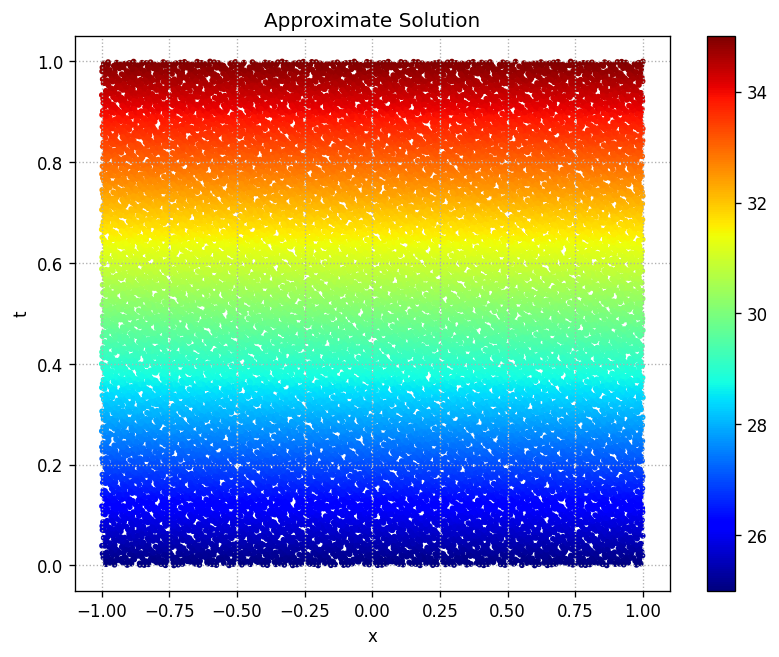

In [15]:
pinn.plotting()

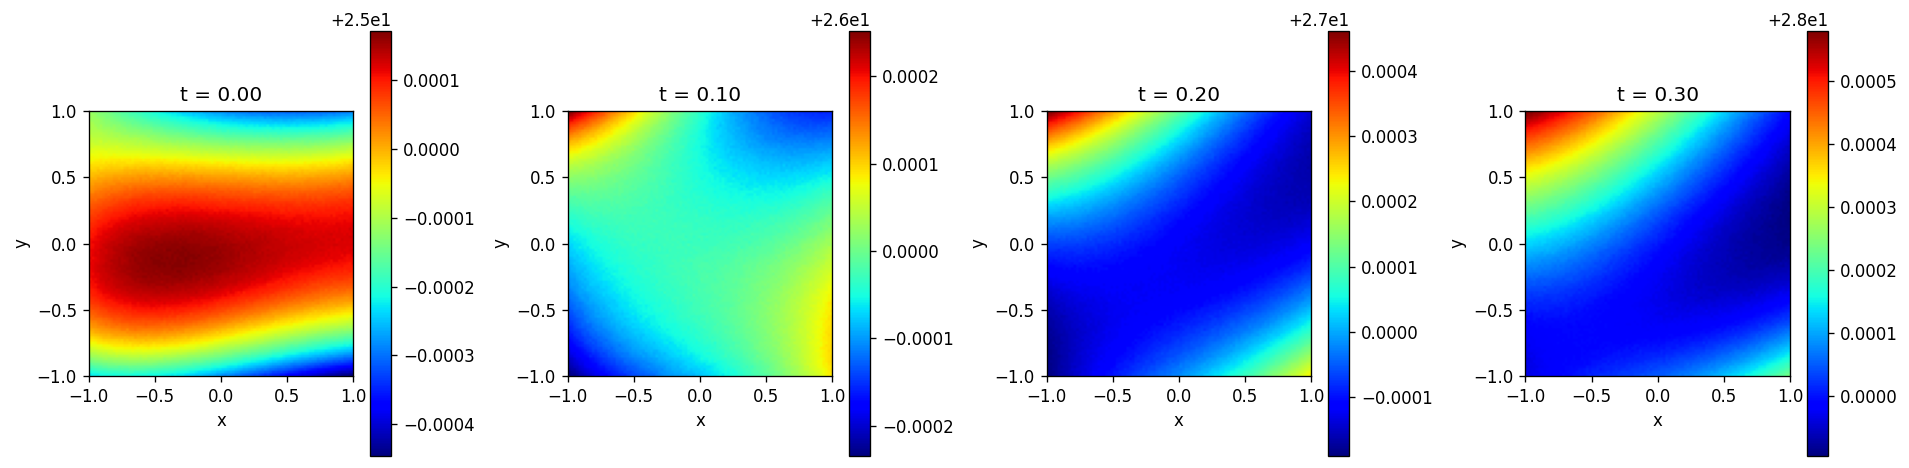

In [16]:
pinn.plotting_2d_xy()